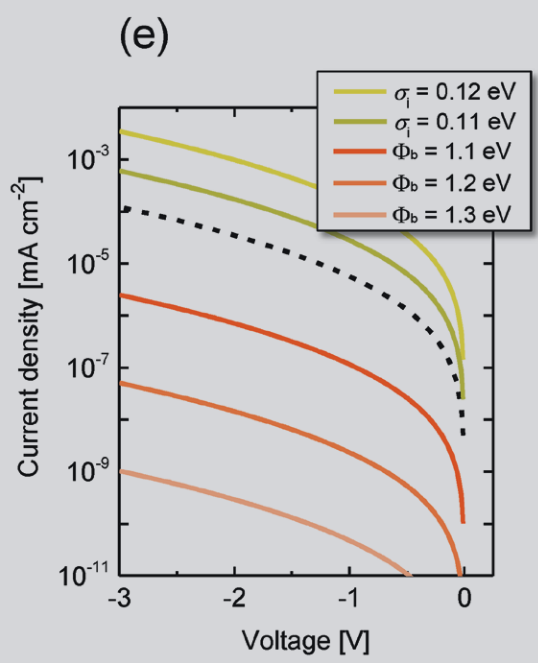

$$
J_d=AqN_t\exp\left[-\frac{\Phi_b-\left(\dfrac{\sigma_i^2}{2k_B T}\right)-\Delta\Phi_b}{k_B T}\right]\cdot\mu_0^{*}
\exp\left[-C_i\left(\dfrac{\sigma_b}{k_B T}\right)^2\right]\cdot\frac{V}{L}
$$  


$$ J_d ∝ \exp(-{\sigma_i}^2) $$

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy.constants
from mpl_toolkits.mplot3d.axes3d import Axes3D # 3D 
from matplotlib import markers
import matplotlib.ticker as ticker
q = 1.602176634e-19
eps0 = 8.854187817e-12
kB_eV = 8.617333262e-5
T = 300
eps_r = 3.5
eps = eps_r * eps0
Phi_b = 1.0
L = 200e-9
# constants
A = 1.0          # m^2（如果只比较趋势，可以设为1）
Nt = 1.0         # m^-3（归一化即可）
mu0 = 1e-8       # m^2/(V·s)
Ci = 0.42
sigma_b = 0.09   # eV

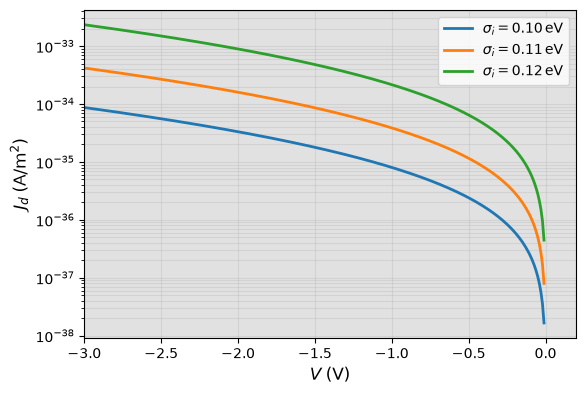

In [4]:
sigmais = np.array([0.10, 0.11, 0.12]) 
V = np.linspace(-3, -0.01, 300)  

fig = plt.figure(figsize=(6, 4), facecolor="white")
ax = fig.add_axes(
    (0.12, 0.12, 0.82, 0.82),
    facecolor="#e1e1e1")

for sigma_i in sigmais:
    F = np.abs(V) / L
    DeltaPhi = np.sqrt(
        q * F / (4 * np.pi * eps)
    )
    arg = -(
        Phi_b
        - sigma_i**2 / (2 * kB_eV * T)
        - DeltaPhi
    ) / (kB_eV * T)
    mobility = mu0 * np.exp(-Ci * (sigma_b / (kB_eV * T))**2)
    J = (A* q* Nt* mobility* F* np.exp(arg))
    ax.semilogy(V,J,linewidth=2,
        label=rf"$\sigma_i={sigma_i:.2f}\,\mathrm{{eV}}$")

ax.set_xlabel(r"$V\;(\mathrm{V})$", fontsize=12)
ax.set_ylabel(r"$J_d\;(\mathrm{A/m^2})$", fontsize=12)

ax.set_xlim(-3, 0.2)
ax.grid(True, which="both", alpha=0.3)
ax.legend()

plt.show()